# 🔥 Wildfire Risk Modeling & Susceptibility Mapping
## Use Case: Machine Learning Approach for California

### Imports and Earth Engine setup

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# Initialize Earth Engine
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# Configuration
ROI = ee.Geometry.Rectangle([-121.0, 37.0, -119.0, 39.0])  # Sierra Nevada, CA
START_DATE = '2020-01-01'
END_DATE = '2023-12-31'

Map = geemap.Map(center=[38.0, -120.0], zoom=8)
Map.addLayer(ROI, {}, 'Study Area')
print("Earth Engine Initialized")
Map


Earth Engine Initialized


Map(center=[38.0, -120.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### Fires and non fire points

In [2]:
# 1. Historical Fire Points (Presence)
fires = ee.ImageCollection('FIRMS') \
    .filterBounds(ROI) \
    .filterDate(START_DATE, END_DATE) \
    .select('T21')

# Simple fire mask based on brightness temperature
fire_mask = fires.max().gt(300).clip(ROI)  # Temperatures > 300K

fire_points = fire_mask.reduceToVectors(
    geometry=ROI,
    scale=1000,
    geometryType='centroid'
)

# 2. Non Fire Points (Absence)
non_fire_points = ee.FeatureCollection.randomPoints(ROI, points=2000)

print(f"Fire Points: {fire_points.size().getInfo()}")
print(f"Non Fire Points: {non_fire_points.size().getInfo()}")

Map.addLayer(fire_points, {'color': 'red'}, 'Fire Occurrences')
Map.addLayer(non_fire_points, {'color': 'green'}, 'Non Fire Points')
Map


Fire Points: 133
Non Fire Points: 2000


Map(center=[38.0, -120.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### Predictor layers and sampling

In [3]:
# Load Predictor Layers
dem = ee.Image('USGS/SRTMGL1_003').clip(ROI)
slope = ee.Terrain.slope(dem)
aspect = ee.Terrain.aspect(dem)
ndvi = ee.ImageCollection('MODIS/006/MOD13A2') \
    .filterDate(START_DATE, END_DATE) \
    .mean() \
    .select('NDVI') \
    .clip(ROI)

temp = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY") \
    .filterDate(START_DATE, END_DATE) \
    .mean() \
    .select('temperature_2m') \
    .clip(ROI)

predictors = slope.addBands(aspect).addBands(ndvi).addBands(temp) \
    .rename(['Slope', 'Aspect', 'NDVI', 'Temp'])


def extract_features(features, label):
    return predictors.sampleRegions(
        collection=features,
        properties=[],
        scale=1000
    ).map(lambda f: f.set('Fire', label))


training_fire = extract_features(fire_points, 1)
training_non_fire = extract_features(non_fire_points, 0)

training_data = training_fire.merge(training_non_fire)

data_list = training_data.limit(5000).getInfo()['features']
df = pd.DataFrame([f['properties'] for f in data_list])

print(f"Extracted dataset with {len(df)} samples")
df.head()


Extracted dataset with 2123 samples


,Aspect,Fire,NDVI,Slope,Temp
0,97.916328,1,2649.416667,6.288018,277.142825
1,45.034599,1,2712.944444,1.189249,276.288479
2,297.757874,1,2531.347222,3.666725,279.372122
3,50.088383,1,1139.861111,5.986310,283.277835
4,318.844543,1,2439.750000,1.616371,277.597268


### EDA

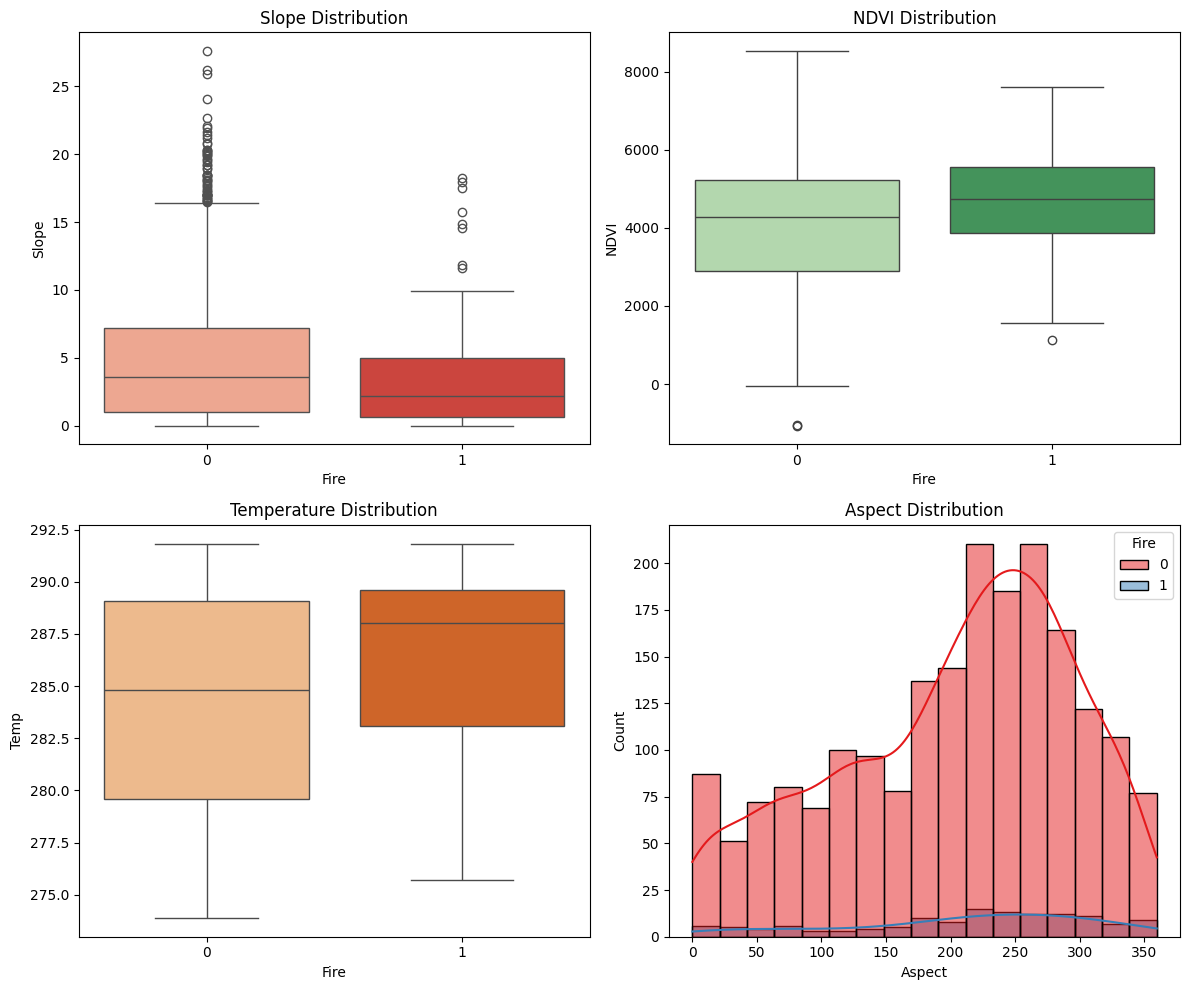

In [4]:
# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=df, x='Fire', y='Slope', ax=axes[0, 0], palette='Reds')
axes[0, 0].set_title('Slope Distribution')

sns.boxplot(data=df, x='Fire', y='NDVI', ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('NDVI Distribution')

sns.boxplot(data=df, x='Fire', y='Temp', ax=axes[1, 0], palette='Oranges')
axes[1, 0].set_title('Temperature Distribution')

sns.histplot(data=df, x='Aspect', hue='Fire', kde=True, ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Aspect Distribution')

plt.tight_layout()
plt.show()


### Train model

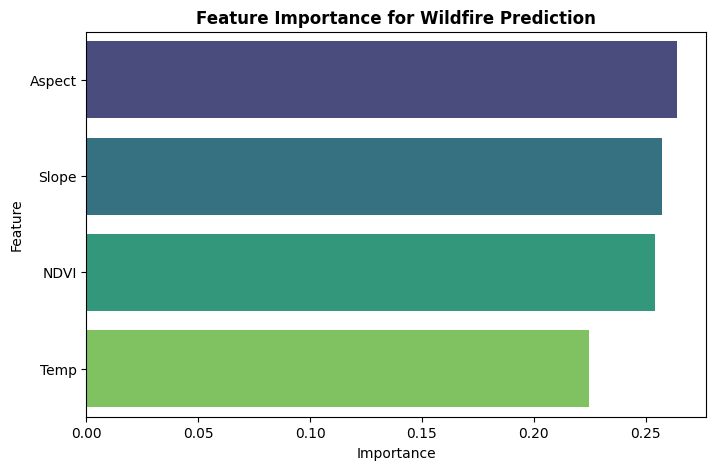

In [5]:
# Train or Test Split
X = df[['Slope', 'Aspect', 'NDVI', 'Temp']]
y = df['Fire']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance for Wildfire Prediction', fontweight='bold')
plt.show()


### Evaluation

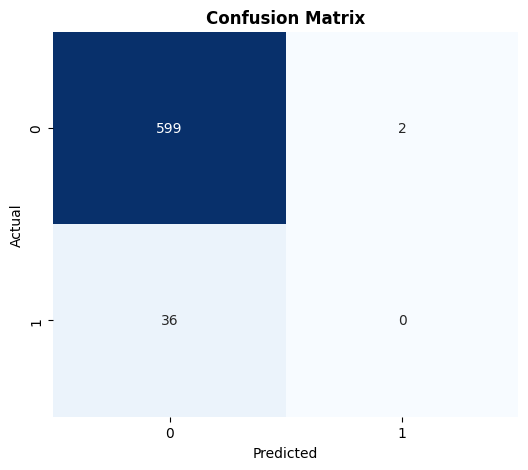

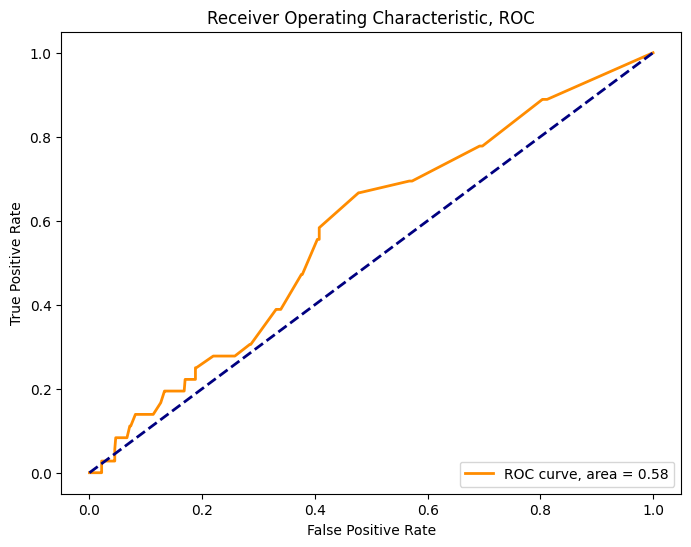

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       601
           1       0.00      0.00      0.00        36

    accuracy                           0.94       637
   macro avg       0.47      0.50      0.48       637
weighted avg       0.89      0.94      0.91       637



In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', fontweight='bold')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve, area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic, ROC')
plt.legend(loc='lower right')
plt.show()

print(classification_report(y_test, y_pred))


### Risk map and summary

In [7]:
# Simple risk index using normalized predictors
norm_slope = slope.divide(90)
norm_temp = temp.subtract(273).divide(50)  # Kelvin to approximate scale
norm_ndvi = ndvi.multiply(-1).add(1).divide(2)  # Invert NDVI, drier is riskier

risk_map = norm_slope.multiply(0.4) \
    .add(norm_temp.multiply(0.3)) \
    .add(norm_ndvi.multiply(0.3))

risk_vis = {
    'min': 0.2,
    'max': 0.8,
    'palette': ['green', 'yellow', 'orange', 'red', 'darkred']
}
Map.addLayer(risk_map, risk_vis, 'Modeled Wildfire Susceptibility')
Map.add_colorbar(risk_vis, label='Risk Index')
Map


Map(bottom=25579.0, center=[38.0, -120.0], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…